In [1]:
from sklearn.datasets import load_breast_cancer

from config.config import N_QUBITS, N_POINTS, SEED
from config.experiments import ExperimentConfig

from src.data.preprocessing import preprocess
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.training_candidate import train_candidate_optuna
from src.optimization.training_svm import run_svm_prediction
from src.optimization.classical_base import classical_baseline
from src.optimization.pipeline import get_candidate
from src.data.subsets import subset_random
from src.utils.visuals import graph_subset

/Users/martadelarosanunez/Github/Automatic_Design_QFM_Genomic_Classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


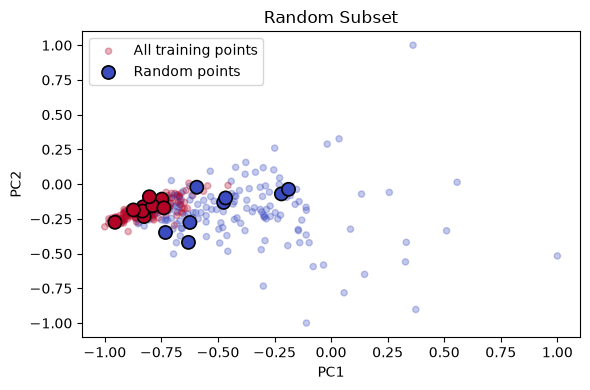

[I 2026-06-24 18:55:12,487] A new study created in memory with name: no-name-7c1498f3-1706-4ead-a3e1-ef6b8771c356
[I 2026-06-24 18:55:13,887] Trial 0 finished with value: 2.4880070367596545 and parameters: {'gate_0': 'H', 'angle_0': 1.2811552008015092, 'gate_1': 'I', 'angle_1': 1.4291124646767015, 'gate_2': 'RY', 'angle_2': 1.9509022411539576, 'gate_3': 'RY', 'angle_3': 1.0615215103828903, 'gate_4': 'CNOT', 'angle_4': 5.049988623641676, 'gate_5': 'CNOT', 'angle_5': 0.9325772185107087, 'gate_6': 'H', 'angle_6': 0.4053232511705289, 'gate_7': 'RZ', 'angle_7': 3.187751187231651, 'gate_8': 'RX', 'angle_8': 3.28015232265637, 'gate_9': 'RY', 'angle_9': 3.790456621069997, 'gate_10': 'H', 'angle_10': 3.336524236853616, 'gate_11': 'RZ', 'angle_11': 1.1103522438293016, 'gate_12': 'CNOT', 'angle_12': 2.396276759601082, 'gate_13': 'RY', 'angle_13': 3.2803424857499373, 'gate_14': 'RY', 'angle_14': 0.0887011331821915, 'gate_15': 'CNOT', 'angle_15': 4.115861081841855}. Best is trial 0 with value: 2.48

Saved → Results/training_optuna_random_100.pkl
Best g (subset):  43.921019889058904


In [3]:
dataset = load_breast_cancer()
X, y, = dataset.data, dataset.target

X_train, X_test, y_train, y_test = preprocess(X, y, N_QUBITS)

# Define the subset
_, X_train_random, y_train_random = subset_random(X_train, y_train, N_POINTS, SEED)
graph_subset('Random', X_train, X_train_random, y_train, y_train_random)

# Train candidate
g_best, best_candidate, K_quantum_best, K_classical = train_candidate_optuna('random', X_train_random, y_train_random)
print("Best g (subset): ", g_best)

# Train the SVM

In [4]:
experiments = [
    ExperimentConfig('optuna_random', 'random', 'optuna', subset_kwargs={'n_sample': 20, 'seed': SEED}),
    #ExperimentConfig('mealpy_nystrom', 'nystrom_global', 'mealpy', subset_kwargs={'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS}),
    #ExperimentConfig('reuse_old_run', 'random', 'optuna', load_from='training_optuna_random_100'),  # <- resumed run
]

results = {}
for cfg in experiments:
    candidate, K_q, K_c, X_sub, y_sub = get_candidate(cfg, X_train, y_train)
    K_test_cross = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    results[cfg.name] = run_svm_prediction(cfg.name, K_q, y_sub, K_test_cross, y_test)

classical = classical_baseline(X_train, y_train, X_test, y_test)

[I 2026-06-24 18:59:18,630] A new study created in memory with name: no-name-793c58d5-f949-4cd1-991f-cde33540452f
[I 2026-06-24 18:59:20,023] Trial 0 finished with value: 11.169349312815765 and parameters: {'gate_0': 'RY', 'angle_0': 5.695382619290352, 'gate_1': 'RX', 'angle_1': 1.67818042869077, 'gate_2': 'RX', 'angle_2': 1.59907079671627, 'gate_3': 'RX', 'angle_3': 5.420252112913738, 'gate_4': 'RZ', 'angle_4': 3.1802570002643944, 'gate_5': 'I', 'angle_5': 3.7275825949137826, 'gate_6': 'I', 'angle_6': 3.030071505362394, 'gate_7': 'RY', 'angle_7': 2.1261595895637693, 'gate_8': 'RY', 'angle_8': 1.6674864283502144, 'gate_9': 'RY', 'angle_9': 5.7064892103712435, 'gate_10': 'CNOT', 'angle_10': 1.77334551081062, 'gate_11': 'RZ', 'angle_11': 0.9410911434712504, 'gate_12': 'CNOT', 'angle_12': 4.545531237905109, 'gate_13': 'RZ', 'angle_13': 2.6354390059768407, 'gate_14': 'CNOT', 'angle_14': 2.8013812515991208, 'gate_15': 'CNOT', 'angle_15': 0.35647188693921084}. Best is trial 0 with value: 11.

Saved → Results/training_optuna_optuna_random_100.pkl
Saved -> Results/optuna_random.pkl
REPORT: optuna_random | 100 iterations
Best C:  10
Best CV accuracy:  0.9
              precision    recall  f1-score   support

          -1       0.98      0.83      0.90        63
           1       0.91      0.99      0.95       108

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171

Saved -> Results/Classical_baseline.pkl
REPORT: Classical_baseline
Best C: 1000
Best CV accuracy: 0.9547468354430378
              precision    recall  f1-score   support

          -1       0.97      0.94      0.95        63
           1       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171

